In [12]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<font size="5" color="black">ch2. 한글 형태소 분석 및 시각화</font>

# 1. 자연어 처리

- 자연어 : 일상적인 언어
- 자연어 처리 분야
    * 탐색(이해) : 형태소 분석 -> pos tagging (품사 태깅) -> 의미 분석 또는 시각화
    * 모델 생성 : RNN, LSTM, GRU, seq2seq, transformer
 
 
# 2. 자연어 처리 절차

- 분석 후보 생성 : 형태소 분리, 품사 태깅
- 제약 조건 : 규칙 확인 및 불용어 처리
- 분석 : 시각화(워드클라우드, plot), 유사도 분석, 연관 분석, RNN, LSTM, GRU, seq2seq, transformer


# 3. 한글 형태소 분석 엔진(Konlpy, ...)

    - 공통기능 : morphs(형태소 분리), pos(형태소 단위 품사 태깅), nouns(명사 추출)

- Konlpy (pip install konlpy)
    * 자바로 만든 형태소 분석기 : HanNanum, Kkma, Komoran (JAVA_HOME 시스템 환경변수, path 설정 필요)
    * Okt(Twitter)
- Mecab(pip install python-mecab-ko)
    * MeCab
        - C++로 만든 형태소 분석기
        - 저사양환경에서 사용 가능
        - 다국어 바인딩 지원
- Konlp : R용 자연어 처리기

In [1]:
import os
os.environ.get('JAVA_HOME')

'C:\\Program Files\\Java\\jdk-17'

In [2]:
import konlpy
konlpy.__version__

'0.6.0'

## 3.1 HanNanum

In [3]:
text = '''
아름답지만 다소 복잡하기도 한 한국어는 전세계에서 13번째로
많이 사용되는 언어입니다
'''

In [4]:
from konlpy.tag import Hannanum
hannanum = Hannanum(jvmpath=None,
                   max_heap_size=512) # 기본값 : 1024, '1024m', '1g' 최대사이즈 4g
hannanum.analyze(text) # text 분석 후 형태소, 품사를 반환 (ntag=69로 형태소 분석)

[[[('아름답', 'paa'), ('지만', 'ecs')],
  [('아름답', 'paa'), ('지', 'ecs'), ('만', 'jxc')],
  [('아름답', 'paa'), ('지', 'ecx'), ('말', 'px'), ('ㄴ', 'etm')]],
 [[('다소', 'mag')], [('다소', 'ncn')]],
 [[('복잡', 'ncn'), ('하기', 'ncn'), ('도', 'jxc')],
  [('복잡', 'ncn'), ('하기', 'ncn'), ('도', 'ncn')],
  [('복잡', 'ncps'), ('하기', 'ncn'), ('도', 'jxc')],
  [('복잡', 'ncps'), ('하기', 'ncn'), ('도', 'ncn')],
  [('복잡', 'ncps'), ('하', 'xsms'), ('기', 'etn'), ('도', 'jxc')]],
 [[('하', 'pvg'), ('ㄴ', 'etm')],
  [('한', 'nnc')],
  [('한', 'ncn')],
  [('한', 'nbn')],
  [('하', 'px'), ('ㄴ', 'etm')]],
 [[('한국어', 'ncn'), ('는', 'jxc')]],
 [[('전세계', 'ncn'), ('에서', 'jca')],
  [('전세', 'ncn'), ('계', 'ncn'), ('에서', 'jca')],
  [('전', 'xp'), ('세계', 'ncn'), ('에서', 'jca')]],
 [[('13', 'nnc'), ('번', 'nbu'), ('째', 'xsnu'), ('로', 'jca')]],
 [],
 [[('많', 'paa'), ('이', 'xsa')], [('많이', 'mag')]],
 [[('사용', 'ncpa'), ('되', 'xsvn'), ('는', 'etm')]],
 [[('언어', 'ncn'), ('이', 'jp'), ('ㅂ니다', 'ef')]]]

- Korean POS tags comparison chart.xlsx 다운로드
    - Konlpy.org → API → KoNLPy

In [5]:
# 형태소 분석 : morphs
print(hannanum.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '하', 'ㄴ', '한국어', '는', '전세계', '에서', '13번', '째', '로', '많', '이', '사용', '되', '는', '언어', '이', 'ㅂ니다']


In [6]:
# 명사만 추출 : nouns
print(hannanum.nouns(text))

['복잡', '한국어', '전세계', '13번', '사용', '언어']


In [7]:
# 품사 태깅 : pos
print(hannanum.pos(text, ntags=22))

[('아름답', 'PA'), ('지만', 'EC'), ('다소', 'MA'), ('복잡', 'NC'), ('하', 'XS'), ('기', 'ET'), ('도', 'JX'), ('하', 'PV'), ('ㄴ', 'ET'), ('한국어', 'NC'), ('는', 'JX'), ('전세계', 'NC'), ('에서', 'JC'), ('13', 'NN'), ('번', 'NB'), ('째', 'XS'), ('로', 'JC'), ('많', 'PA'), ('이', 'XS'), ('사용', 'NC'), ('되', 'XS'), ('는', 'ET'), ('언어', 'NC'), ('이', 'JP'), ('ㅂ니다', 'EF')]


In [8]:
# ex1. text에서 형용사(PA)만 추출
tagged_text = hannanum.pos(text, ntags=22)
words = [token for token, tag in tagged_text if tag=='PA']
print(words)

['아름답', '많']


In [9]:
# ex2. text에서 명사(NC, NQ, NP, NN)만 추출
tags = ['NC', 'NQ', 'NP', 'NN']
words = [token for token, tag in tagged_text if tag in tags]
words

['복잡', '한국어', '전세계', '13', '사용', '언어']

In [10]:
# ex3. text에서 보통명사(NC)만 추출
tags = ['NC']
words = [token for token, tag in tagged_text if tag in tags]
words

['복잡', '한국어', '전세계', '사용', '언어']

## 3.2 Kkma

In [5]:
from konlpy.tag import Kkma

In [6]:
kkma = Kkma()

In [7]:
text = '''
아름답지만 다소 복잡하기도 한 한국어는 전세계에서 13번째로
많이 사용되는 언어입니다
'''

In [8]:
# 형태소 분석
print(kkma.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '한', '한국어', '는', '전세계', '에서', '13', '번째', '로', '많이', '사용', '되', '는', '언어', '이', 'ㅂ니다']


In [9]:
# 품사 태깅
print(kkma.pos(text)) # ntags 지정 불가 (무조건 56으로)

[('아름답', 'VA'), ('지만', 'ECE'), ('다소', 'MAG'), ('복잡', 'NNG'), ('하', 'XSV'), ('기', 'ETN'), ('도', 'JX'), ('한', 'MDN'), ('한국어', 'NNG'), ('는', 'JX'), ('전세계', 'NNG'), ('에서', 'JKM'), ('13', 'NR'), ('번째', 'NNB'), ('로', 'JKM'), ('많이', 'MAG'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETD'), ('언어', 'NNG'), ('이', 'VCP'), ('ㅂ니다', 'EFN')]


In [10]:
# 품사태깅을 이용한 명사(NNG, NNP, NP) 추출
tagged_text = kkma.pos(text)
words = [token for token, tag in tagged_text if tag in ('NNG', 'NNP', 'NP')]
print(words)

['복잡', '한국어', '전세계', '사용', '언어']


In [11]:
# nouns함수를 이용한 명사 추출
print(kkma.nouns(text))

['복잡', '한국어', '전세계', '13', '13번째', '번째', '사용', '언어']


## 3.3 Komoran

In [1]:
text = '''
아름답지만 다소 복잡하기도 한 한국어는 전세계에서 13번째로
많이 사용되는 언어입니다
'''

In [2]:
from konlpy.tag import Komoran
komoran = Komoran()

In [3]:
# 형태소 분석
print(komoran.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '한', '한국어', '는', '전', '세계', '에서', '13', '번', '째', '로', '많이', '사용', '되', '는', '언어', '이', 'ㅂ니다']


In [4]:
# 명사 추출
print(komoran.nouns(text))

['한국어', '전', '세계', '번', '사용', '언어']


In [5]:
# 품사 태깅 (pos tagging)
tagged_list = komoran.pos(text)
print(tagged_list)

[('아름답', 'VA'), ('지만', 'EC'), ('다소', 'MAG'), ('복잡', 'XR'), ('하', 'XSA'), ('기', 'ETN'), ('도', 'JX'), ('한', 'MM'), ('한국어', 'NNP'), ('는', 'JX'), ('전', 'NNG'), ('세계', 'NNG'), ('에서', 'JKB'), ('13', 'SN'), ('번', 'NNB'), ('째', 'XSN'), ('로', 'JKB'), ('많이', 'MAG'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETM'), ('언어', 'NNG'), ('이', 'VCP'), ('ㅂ니다', 'EC')]


In [6]:
# 일반 명사 (NNG) + 고유 명사 (NNP) 추출
print([token for token, tag in tagged_list if tag in ('NNG', 'NNP')])

['한국어', '전', '세계', '사용', '언어']


## 3.4 Okt (Twitter)
- 2018년 KoNLPy v0.4.5 업데이트부터 오픈소스 이름 변경 : Twitter → Okt(Open Korean Text)
- 정제되지 않은 SNS/인터넷 텍스트 분석에 특화
- Scala로 작성되어 JVM 상에서 구동
- 속도가 매우 빠르고 메모리 점유율이 적어 대용량 텍스트 처리에 유리

In [8]:
from konlpy.tag import Twitter, Okt
okt = Okt()

In [9]:
# 명사구 추출
print('명사구 추출 :', okt.phrases(text))

명사구 추출 : ['다소', '한국어', '전세계', '13번째', '사용', '사용되는 언어', '13', '번째', '언어']


In [10]:
# 형태소 분석
print('형태소 분석 :', okt.morphs(text))

형태소 분석 : ['\n', '아름답지만', '다소', '복잡하기도', '한', '한국어', '는', '전세계', '에서', '13', '번', '째', '로', '\n', '많이', '사용', '되는', '언어', '입니다', '\n']


In [11]:
# 명사만 추출
print(okt.nouns(text))

['다소', '한국어', '전세계', '번', '사용', '언어']


In [12]:
# 품사 태깅
tagged_list = okt.pos(text)
print(tagged_list)

[('\n', 'Foreign'), ('아름답지만', 'Adjective'), ('다소', 'Noun'), ('복잡하기도', 'Adjective'), ('한', 'Verb'), ('한국어', 'Noun'), ('는', 'Josa'), ('전세계', 'Noun'), ('에서', 'Josa'), ('13', 'Number'), ('번', 'Noun'), ('째', 'Suffix'), ('로', 'Josa'), ('\n', 'Foreign'), ('많이', 'Adverb'), ('사용', 'Noun'), ('되는', 'Verb'), ('언어', 'Noun'), ('입니다', 'Adjective'), ('\n', 'Foreign')]


In [13]:
# 명사(Noun)만 추출
print([word for word, tag in tagged_list if tag == 'Noun'])

['다소', '한국어', '전세계', '번', '사용', '언어']


## 3.5 MeCab
- pip install python-mecab-ko
- C++ 기반의 압도적 속도 (Konlpy 대비 5~20배 빠른 속도)
    - 속도가 매우 빠르고 메모리 효율이 뛰어남
- KoNLPy 패키지 바인딩 지원
- 실무 NLP 서비스에서 가장 표준적으로 사용되는 한국어 형태소 분석기 (네이버, 카카오, 라인 등에서 mecab 계열 사용한 사례 다수)

In [14]:
from mecab import MeCab
mecab = MeCab()

In [15]:
# 형태소 분석
print(mecab.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '한', '한국어', '는', '전', '세계', '에서', '13', '번', '째', '로', '많이', '사용', '되', '는', '언어', '입니다']


In [16]:
# 명사 추출
print(mecab.nouns(text))

['한국어', '세계', '번', '사용', '언어']


In [17]:
# 품사 태깅
tagged_list = mecab.pos(text)
print(tagged_list)

[('아름답', 'VA'), ('지만', 'EC'), ('다소', 'MAG'), ('복잡', 'XR'), ('하', 'XSA'), ('기', 'ETN'), ('도', 'JX'), ('한', 'MM'), ('한국어', 'NNG'), ('는', 'JX'), ('전', 'MM'), ('세계', 'NNG'), ('에서', 'JKB'), ('13', 'SN'), ('번', 'NNBC'), ('째', 'XSN'), ('로', 'JKB'), ('많이', 'MAG'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETM'), ('언어', 'NNG'), ('입니다', 'VCP+EC')]


In [18]:
# 명사(NNG, NNP, NP, NR) 추출
print([token for token, tag in tagged_list if tag in ('NNG', 'NNP', 'NP', 'NR')])

['한국어', '세계', '사용', '언어']


# 4. 말뭉치

In [4]:
# 영어 말뭉치
import nltk
emma = nltk.corpus.gutenberg.raw('austen-emma.txt')
print(emma[:30])

[Emma by Jane Austen 1816]

VO


In [5]:
%pip show konlpy

Name: konlpy
Version: 0.6.0
Summary: Python package for Korean natural language processing.
Home-page: http://konlpy.org
Author: Team KoNLPy
Author-email: konlpy@googlegroups.com
License: GPL v3
Location: c:\users\admin\anaconda3\envs\ml-dl-nlp\lib\site-packages
Requires: JPype1, lxml, numpy
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [6]:
# 한국어 말뭉치
from konlpy.corpus import kolaw
kolaw_data = kolaw.open('constitution.txt').read()

In [7]:
# 글자 수
print('글자 수 :', len(kolaw_data))

글자 수 : 18884


In [8]:
# 로우 데이터 확인
print('%r' % kolaw_data[:58])

'대한민국헌법\n\n유구한 역사와 전통에 빛나는 우리 대한국민은 3·1운동으로 건립된 대한민국임시정부의 법통과'


# 5. 워드 클라우드
- pip install wordcloud

In [9]:
nouns = ['word1','word2','word1']
' '.join(nouns)

'word1 word2 word1'

In [13]:
# 영어 말뭉치에서 2글자 이상의 명사 추출
from nltk.tokenize import RegexpTokenizer
from nltk.tag import pos_tag
ret = RegexpTokenizer('\w{2,}')
words = ret.tokenize(emma)
emma_tags = pos_tag(words)

In [14]:
# 명사 추출 (NN_s)
noun_list = [token for token, tag in emma_tags if tag in ('NN', 'NNS', 'NNP', 'NNPS')]
print('추출한 명사 개수 :', len(noun_list), ', 단어 종류 수 :', len(set(noun_list)))

추출한 명사 개수 : 32618 , 단어 종류 수 : 4111


In [15]:
# 워드 클라우드 출력을 위한 전처리
emma_noun = ' '.join(noun_list)
print('워드 클라우드에서 필요한 text :', emma_noun[:50])

워드 클라우드에서 필요한 text : Emma Jane Austen VOLUME CHAPTER Emma Woodhouse cle


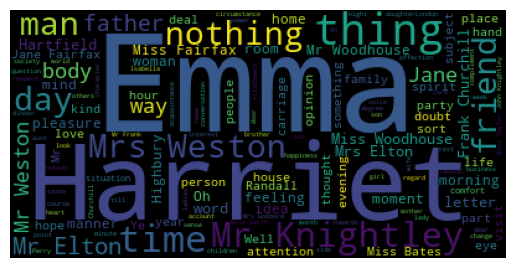

In [16]:
# 워드 클라우드 출력
from wordcloud import WordCloud
from matplotlib import pyplot as plt

wordcloud = WordCloud()
wordcloud.generate(emma_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

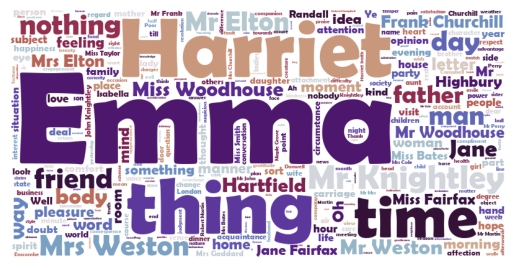

In [17]:
wordcloud = WordCloud(font_path='C:/Windows/Fonts/BRLNSDB.TTF', # 글자 폰트
                      width=800, # 가로 사이즈 (기본값 : 400)
                      height=400, # 세로 사이즈 (기본값 : 200)
                      background_color='white', # 배경색
                      max_words=300, # 표시할 단어의 최대 개수
                      relative_scaling=0.8, # 빈도에 따른 크기 조절
                      colormap='twilight_shifted'
                     )
wordcloud.generate(emma_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [18]:
# 생성한 워드 클라우드 저장 - 가로 사이즈 * 세로 사이즈 크기의 이미지 파일로 저장
wordcloud.to_file('emma.png')

In [19]:
# 한글 말뭉치
import pandas as pd
from mecab import MeCab
from nltk import FreqDist
from konlpy.corpus import kolaw

mecab = MeCab()
tagged_list = mecab.pos(kolaw_data)

noun_list = [token for token, tag in tagged_list if tag in ('NNG', 'NNP')]

# 빈도수 계산 및 상위 10개 출력
noun_wordcount = FreqDist(noun_list)
wordCnt = pd.Series(noun_wordcount)
wordCnt.sort_values(ascending=False, inplace=True)
wordCnt.head(10)

법률     121
대통령     84
조       79
국가      73
헌법      69
국민      69
국회      69
때       55
필요      31
위원      30
dtype: int64

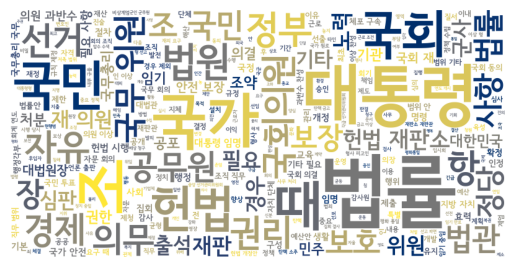

In [27]:
kolaw_noun = ' '.join(noun_list)

wordcloud = WordCloud(font_path='C:/Windows/Fonts/SeoulNamsanEB.ttf',
                      width=800,
                      height=400,
                      background_color='white',
                      max_words=300,
                      relative_scaling=0.5,
                      colormap='cividis'
                     )
wordcloud.generate(kolaw_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [22]:
wordcloud.to_file('kolaw.png')

In [71]:
# 불용어 처리
from wordcloud import STOPWORDS
from nltk.corpus import stopwords

print('월드 클라우드 라이브러리의 불용어 목록\n', stopwords.fileids())

stopword = {'조', '대통령', '법률', '때'}
print(stopword)

월드 클라우드 라이브러리의 불용어 목록
 ['albanian', 'arabic', 'azerbaijani', 'basque', 'belarusian', 'bengali', 'catalan', 'chinese', 'danish', 'dutch', 'english', 'finnish', 'french', 'german', 'greek', 'hebrew', 'hinglish', 'hungarian', 'indonesian', 'italian', 'kazakh', 'nepali', 'norwegian', 'portuguese', 'romanian', 'russian', 'slovene', 'spanish', 'swedish', 'tajik', 'tamil', 'turkish', 'uzbek']
{'조', '대통령', '법률', '때'}


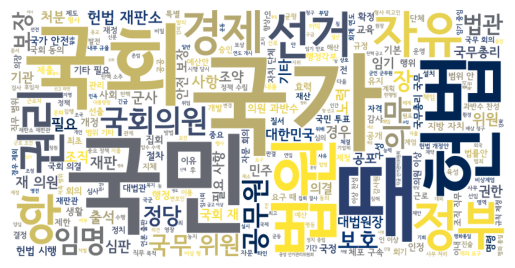

In [43]:
kolaw_noun = ' '.join(noun_list)

wordcloud = WordCloud(font_path='C:/Windows/Fonts/SeoulNamsanEB.ttf',
                      width=800,
                      height=400,
                      background_color='white',
                      max_words=300,
                      relative_scaling=0.5,
                      colormap='cividis',
                      stopwords=stopword # 불용어 처리
                     )
wordcloud.generate(kolaw_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

(1600, 1600, 4)
<class 'numpy.ndarray'>


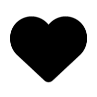

In [56]:
import cv2
import matplotlib.pyplot as plt

mask = cv2.imread('data/heart.png', cv2.IMREAD_UNCHANGED)

print(mask.shape)
print(type(mask))

plt.figure(figsize=(1, 1), facecolor='white')
plt.imshow(mask)
plt.axis('off')
plt.show()

<class 'PIL.PngImagePlugin.PngImageFile'> <class 'numpy.ndarray'> (1600, 1600, 4)


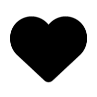

In [62]:
from PIL import Image
import numpy as np

img = Image.open('data/heart.png')
mask = np.array(img)
print(type(img), type(mask), mask.shape)

plt.figure(figsize=(1, 1))
plt.imshow(mask)
plt.axis('off')
plt.show()

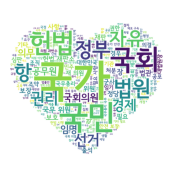

In [73]:
from wordcloud import WordCloud, ImageColorGenerator
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

img = Image.open('data/heart.png')
mask_raw = np.array(img)

# 투명 배경을 255(흰색 배경)로 변환
mask = mask_raw.copy()
if mask.ndim == 3 and mask.shape[2] == 4:
    transparent_area = (mask[:, :, 3] == 0)
    mask[transparent_area] = [255, 255, 255, 255]

kolaw_noun = ' '.join(noun_list)

wordcloud = WordCloud(
    font_path='C:/Windows/Fonts/SeoulNamsanEB.ttf',
    background_color='white',
    max_words=300,
    relative_scaling=0.5,
    stopwords=stopword,
    mask=mask
)

wordcloud.generate(kolaw_noun)

plt.figure(figsize=(2, 2))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

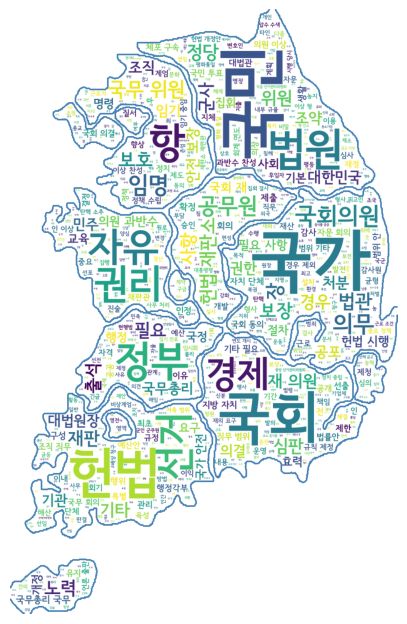

In [82]:
from wordcloud import WordCloud, ImageColorGenerator
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

img = Image.open('data/south_korea.png')
mask = np.array(img)

mask2 = mask.copy()
if mask2.ndim == 3 and mask2.shape[2] == 4:
    transparent_area = (mask2[:, :, 3] == 0)
    mask2[transparent_area] = [255, 255, 255, 255]

kolaw_noun = ' '.join(noun_list)

wordcloud = WordCloud(
    font_path='C:/Windows/Fonts/SeoulNamsanEB.ttf',
    background_color='white',
    max_words=1000,
    relative_scaling=0.5,
    contour_width=2,
    contour_color='steelblue',
    stopwords=stopword,
    mask=mask2
)
wordcloud.generate(kolaw_noun)
plt.figure(figsize=(5, 8))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

# 6. 워드 임베딩

- 단어를 다차원 공간의 벡터(좌표)로 변환하여 단어 간의 거리와 유사도를 계산
- Word2vec : 언어학적 가설(분포 가설)에 기반

- 뉴스 20개의 제목과 내용 속 명사 추출 후 리스트 형태로 출력 (naver API) → 워드 임베딩 (단어 간 거리와 유사도 계산)
    ```
        [['단어1','단어2','단어3',...], 
         ['단어4','단어5','단어6',...], 
         ['단어2','단어7','단어1',...],...]
    ```

In [1]:
# .env 가져오기(방법1) - 강추
from dotenv import load_dotenv
import os
load_dotenv(dotenv_path='C:/ai/source/01_python/.env')

True

In [3]:
import os
import requests
import json
import pandas as pd
client_id = os.getenv('CLIENT_ID')
client_secret = os.getenv('CLIENT_SECRET')

url = f"https://openapi.naver.com/v1/search/news.json"
params = {'query':'경제', 'display':20 ,'sort':'date'}
headers = {
    'X-Naver-Client-Id': client_id,
    'X-Naver-Client-Secret':client_secret
}
response = requests.get(url, params=params, headers=headers)

items = response.json()['items']

# 제목(title) + ' ' + 요약(description) 텍스만 추출하여 리스트 형태로 출력
news_texts = []
for item in items:
    title = item.get('title').replace('<b>', ' ').replace('</b>', ' ')
    description = item.get('description').replace('<b>', ' ').replace('</b>', ' ')
    news_texts.append(title + ' ' + description)
news_texts[:3], len(news_texts)

(['“무주택자 외곽이라도 매수하는 게 유리…상급지로 갈아타기 당분간 어... “무주택자는 지금 여력이 되는 범위에서 매수하는 게 유리합니다.” 김인만 김인만부동산 경제 연구소 대표는 1일 동아일보와의 인터뷰에서 집값은 여전히 높은데 고금리로 대출 부담도 커져 고민인 무주택자들에게... ',
  '‘ 경제 부총리 출신’ 추경호 “미래대응기금, 지방 자주성 훼손” 비판 추경호 대구시장이 정부의 ‘미래대응기금 운용계획’을 정면으로 비판하고 나섰다. 미래대응기금 조성 과정에서 지방정부로 내려가야 할 자주재원이 대폭 줄어든다는 이유에서다. 추 시장은 중앙정부의 일방적인 기금... ',
  '“설득 결과가 상대방에게 도움되는지 답할 수 있어야 좋은 설득” 이 과정을 ‘휴리스틱’이라고 하는데 카너먼은 이 연구로 노벨 경제 학상까지 받았다. 설득은 양날의 칼이다. 사기꾼이 사용하면 사기의 도구이고, 리더가 사용하면 리더십의 도구다. 설득과 사기는 종이 한 장 차이라는... '],
 20)

In [4]:
# 명사 추출 (news_texts)
from konlpy.tag import Hannanum, Kkma, Komoran, Okt
from mecab import MeCab

analyzer = MeCab()

news = []

for article in news_texts:
    noun_list = analyzer.nouns(article)
    noun_list = [word for word, tag in analyzer.pos(article) if tag in ('NNG','NNP')]
    news.append(noun_list)
    
print(news[:3])

[['무주택자', '외곽', '매수', '유리', '상급', '지', '무주택자', '여력', '범위', '매수', '유리', '김인만', '김인만', '부동산', '경제', '연구소', '대표', '동아일보', '인터뷰', '집값', '고금리', '대출', '부담', '고민', '무주택자'], ['경제', '부총리', '출신', '추경호', '미래', '대응', '기금', '지방', '자주', '훼손', '비판', '추경호', '대구', '시장', '정부', '미래', '대응', '기금', '운용', '계획', '정면', '비판', '미래', '대응', '기금', '조성', '과정', '지방', '정부', '재원', '이유', '추', '시장', '중앙', '정부', '일방', '기금'], ['설득', '결과', '상대방', '도움', '답', '설득', '과정', '휴리스틱', '카너먼', '연구', '노벨', '경제', '학상', '설득', '양날', '칼', '사기', '사용', '사기', '도구', '리더', '사용', '리더십', '도구', '설득', '사기', '종이', '차이']]


In [5]:
print([len(nouns) for nouns in news])

[25, 37, 28, 39, 33, 29, 35, 33, 40, 40, 45, 41, 37, 45, 27, 44, 29, 30, 36, 33]


In [6]:
# 워드 임베팅(단어간 거리 계산)
from gensim.models import Word2Vec

model = Word2Vec(
    sentences=news,   # 2차원 리스트 형태의 학습 데이터 (예: [['단어1', '단어2'], ...])
    window=15,        # 타깃 단어 양옆(좌우)으로 참조할 맥락 단어의 최대 거리
    min_count=2,      # 전체 문서에서 최소 2회 이상 등장한 단어만 Vocab에 포함
    workers=4,        # 학습에 사용할 CPU 코어 수
    sg=1              # 1: Skip-gram (소량 데이터/희귀 단어에 유리), 0: CBOW (대량 데이터/속도 빠름)
)

In [7]:
# 학습한 단어 리스트
print(model.wv.index_to_key)

['경제', '서울', '한국', '투자', '인천', '식품', '문화', '기관', '과정', '공사', '명회', '농', '강북', '센터', '데이터', '재단', '시민', '기자', '설득', '정부', '시장', '기금', '미래', '퀴즈', '돈', '워크', '캐시', '신한은행', '인력', '관계자', '공공', '설', '입양', '부', '종', '소스', '파스타', '토마토', '정원', '청', '대상', '단체', '위원회', '스토어', '팝업', '현대', '쿠쿠', '이번', '기획', '한스', '출시', '이마트', '스코리아', '필립', '사기', '도움', '지방', '대응', '무주택자', '문제', '공개', '정답', '오기형', '김장호', '보완', '법', '연합', '사회', '통합', '손님', '매출', '동물', '유기', '협회', '지침', '배치', '반도체', '보장', '치료', '혈전', '가입', '보험', '건강', '김정욱', '참석', '동물보호', '임직원', '연구원', '농촌', '유통', '농수산', '농어촌', '도시', '혁신', '나주', '공연', '저널', '가능', '연희', '전통', '작소', '탈공', '천하제일', '상주', '발생', '반대', '주민', '확산', '진흥', '업무', '산업', '유치', '점', '목동', '백화점', '팩', '케어', '김종효', '칫솔', '전동', '음파', '도구', '사용', '대구', '비판', '추경호', '부담', '대표', '김인만', '범위', '유리', '매수', '외곽']


In [9]:
# 유사도가 가장 높은 단어 (거리가 가까운 단어)
model.wv.most_similar('한국', 
                      topn=10 # n개 출력
                     ) 

[('통합', 0.36984631419181824),
 ('단체', 0.21197085082530975),
 ('스코리아', 0.20174546539783478),
 ('과정', 0.1991206258535385),
 ('참석', 0.18880513310432434),
 ('가능', 0.1821782886981964),
 ('농', 0.17272792756557465),
 ('관계자', 0.17115344107151031),
 ('인천', 0.17018887400627136),
 ('목동', 0.1620526760816574)]

In [10]:
model.wv.most_similar('식품', topn=10) 

[('협회', 0.3076630234718323),
 ('통합', 0.27950748801231384),
 ('치료', 0.2345964014530182),
 ('농촌', 0.20066748559474945),
 ('정답', 0.1904805600643158),
 ('사회', 0.17853693664073944),
 ('농', 0.16694684326648712),
 ('공공', 0.16260263323783875),
 ('유통', 0.1462918221950531),
 ('혁신', 0.14215858280658722)]

In [11]:
# 단어를 입력받아 유사한 단어 5개 출력하기
word = input('단어 입력 : ')
if word in model.wv:
    print(model.wv.most_similar(word, topn=5))
else:
    print(f'{word} 단어는 훈련 데이터에 없습니다')

유사도를 알고 싶은 단어는?외곽
[('케어', 0.17341722548007965), ('사회', 0.1694394201040268), ('전동', 0.15995736420154572), ('목동', 0.15819129347801208), ('가능', 0.14643600583076477)]
